In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot 

In [3]:
df =pd.read_csv('taxi_trip_pricing.csv')

In [4]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [5]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [6]:
col =['Time_of_Day','Day_of_Week','Traffic_Conditions','Weather']
for i in col:
    df[i]=df[i].fillna(df[i].mode()[0])

In [7]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day               0
Day_of_Week               0
Passenger_Count          50
Traffic_Conditions        0
Weather                   0
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

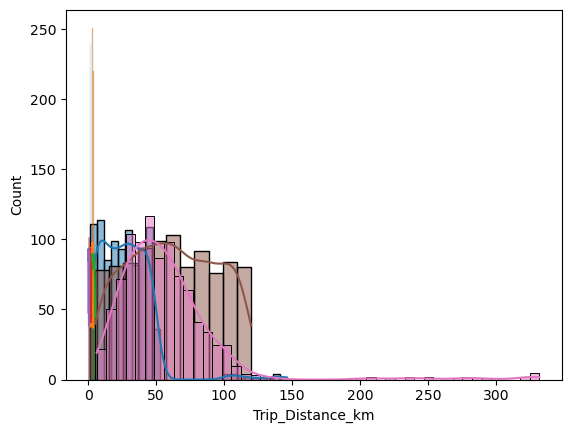

In [8]:
col1 =['Trip_Distance_km','Passenger_Count','Base_Fare','Per_Km_Rate','Per_Minute_Rate','Trip_Duration_Minutes','Trip_Price']
for i in col1:
        sns.histplot(df[i],kde=True)

In [9]:
for i in col1:
    df[i]=df[i].fillna(df[i].mean())

In [10]:
df.isnull().sum()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            1000 non-null   object 
 2   Day_of_Week            1000 non-null   object 
 3   Passenger_Count        1000 non-null   float64
 4   Traffic_Conditions     1000 non-null   object 
 5   Weather                1000 non-null   object 
 6   Base_Fare              1000 non-null   float64
 7   Per_Km_Rate            1000 non-null   float64
 8   Per_Minute_Rate        1000 non-null   float64
 9   Trip_Duration_Minutes  1000 non-null   float64
 10  Trip_Price             1000 non-null   float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [12]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()

In [13]:
col2 =['Time_of_Day','Day_of_Week','Traffic_Conditions','Weather']
for i in col2:
    df[i]=le.fit_transform(df[i])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            1000 non-null   int64  
 2   Day_of_Week            1000 non-null   int64  
 3   Passenger_Count        1000 non-null   float64
 4   Traffic_Conditions     1000 non-null   int64  
 5   Weather                1000 non-null   int64  
 6   Base_Fare              1000 non-null   float64
 7   Per_Km_Rate            1000 non-null   float64
 8   Per_Minute_Rate        1000 non-null   float64
 9   Trip_Duration_Minutes  1000 non-null   float64
 10  Trip_Price             1000 non-null   float64
dtypes: float64(7), int64(4)
memory usage: 86.1 KB


In [15]:
X =df.drop('Trip_Price',axis=1)
y =df['Trip_Price']

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
...     X, y, test_size=0.33, random_state=42)

In [18]:
#from sklearn.preprocessing import StandardScaler
#scaler =StandardScaler()

In [19]:
#X_train_sc =scaler.fit_transform(X_train)
#X_test_sc =scaler.fit_transform(X_test)

In [20]:
#from sklearn.linear_model import LinearRegression

In [21]:
#LI =LinearRegression()

In [22]:
#LI.fit(X_train_sc,y_train)

In [23]:
#ypred =LI.predict(X_test_sc)

In [24]:
from sklearn.metrics import r2_score

Testing

In [25]:
#r2_score(ypred,y_test)

Training

In [26]:
#ypred1 =LI.predict(X_train_sc)


In [27]:
#r2_score(ypred1,y_train)

In [28]:
from sklearn.ensemble import RandomForestRegressor
RF =RandomForestRegressor()

In [29]:
best=RF.fit(X_train,y_train)

In [30]:
y_pred2 =RF.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

Testing

In [32]:
r2_score(y_pred2,y_test)

0.8980524744248551

Training


In [33]:
ypred3 =RF.predict(X_train)

In [34]:
r2_score(ypred3,y_train)

0.9885880214713916

In [35]:
import pickle
with open('model.pkl','wb') as f:
    pickle.dump(best,f)